## Dealing with Overfitting

In order to avoid overfitting during the course of training,
we examine a multitude of regularization approaches.

1. Adding more Data Augmentation Techniques
2. Adding more models to the assembly
3. Weight Regularization
4. Reducing the parameter count
5. Reducing the learning rate

In [7]:
import sys
from google.colab import drive
drive.mount("/content/drive")
PROJECT_ROOT = "/content/drive/MyDrive/Projects/MMSEN"
sys.path.insert(0, PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!kaggle datasets download -d andrewmvd/metastatic-tissue-classification-patchcamelyon
!unzip metastatic-tissue-classification-patchcamelyon.zip

In [8]:
import torch
from torch import nn
from torchvision import transforms, models
from matplotlib import pyplot as plt
import random

from src.data import PCamDataset
from src.models import MMSEN, MMSEN_small
from src.train import train_loop, train_loop_regularization
from src.evaluation import compare_exps
from src.utils import assemble_mmsen, assemble_mmsen_small

ImportError: cannot import name 'assemble_mmsen_small' from 'src.utils' (/content/drive/MyDrive/Projects/MMSEN/src/utils.py)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# define a transform, now normalize using the computed mean and std,
# also add random horizontal and vertical flipping for dataset augmentation

mean = [0.7008, 0.5384, 0.6916]
std = [0.2350, 0.2774, 0.2129]

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

### Adding more Data Augmentation Techniques

In the paper, the authors describe using only random horizontal and vertical flips for data augmentation. <br>
First, we will incorporate random rotations of 90°, 180°, and 270°. <br>
In principle, this should not introduce any drawbacks, as the orientation of the sample under the microscope during image acquisition is arbitrary and should not affect the underlying tissue characteristics. <br>
Thereafter we move to color jitter.
Color jitter is a data augmentation technique that randomly alters an image’s color properties, typically brightness, contrast, saturation, and hue. <br>
This, on the other hand, might interfere with the tissue characteristics,
and should therefore be thoroughly tested.

#### Random Rotations

In [ ]:
class Random90Rotation:
    def __call__(self, x):
        return transforms.functional.rotate(x, random.choice([0, 90, 180, 270]))

# add random rotations
train_transform_wRandomRotations = transforms.Compose([
    transforms.ToPILImage(),  # only if your input is not already PIL
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    Random90Rotation(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [ ]:
mmsen = assemble_mmsen()
mmsen = mmsen.to(device, memory_format=torch.channels_last)

In [ ]:
train_loop(
    mmsen, 
    "mmsen_RandomRotations",
    train_transform_wRandomRotations,
    test_transform,
    custom_lr=True
)

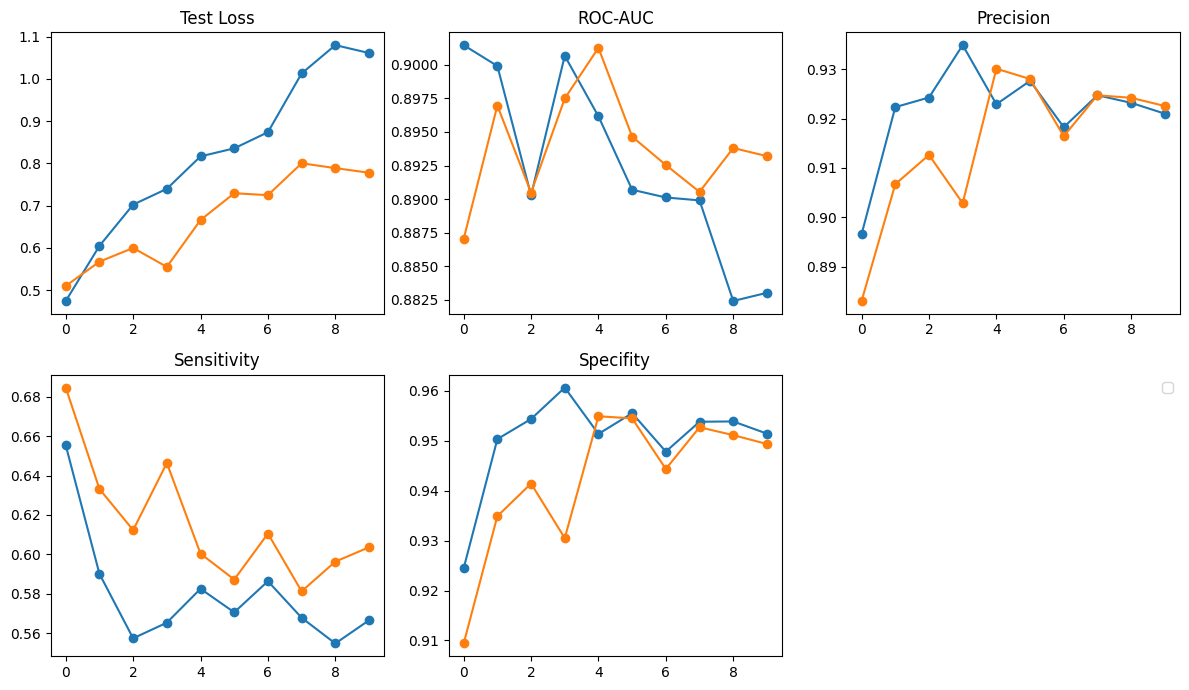

In [6]:
exps = ['mmsen_classifier_10epochs', 'mmsen_RandomRotations']
labels = ['Baseline', 'RandomRotations']
compare_exps(exps, labels)

#### Adding Color Jitter

This might require some domain knowledge.
Skilled physicians recognize cancerous tissue by identifiying lesions. <br>
I do not know whether the characteristics of these lesions are distorted by applying color jitter?

In [ ]:
# load the training data
train_data = PCamDataset('pcam/training_split.h5', 'Labels/Labels/camelyonpatch_level_2_split_train_y.h5', transform=None)

In [ ]:
showcase_transform_lite = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(0.15, 0.15, 0.15, 0.03),
    transforms.ToTensor()
])

showcase_transform_strong = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(0.5, 0.5, 0.5, 0.1),
    transforms.ToTensor()
])

In [ ]:
imgs = [train_data[i][0] for i in range(5)]
imgs_cj_lite = [showcase_transform_lite(img) for img in imgs]
imgs_cj_strong = [showcase_transform_strong(img) for img in imgs]

In [ ]:
fig, axs = plt.subplots(3, 5)

for i in range(5):
  axs[0, i].imshow(imgs[i])
  axs[1, i].imshow(imgs_cj_lite[i].permute(1, 2, 0))
  axs[2, i].imshow(imgs_cj_strong[i].permute(1, 2, 0))

  axs[0, i].set_xticks([])
  axs[0, i].set_yticks([])
  axs[1, i].set_xticks([])
  axs[1, i].set_yticks([])
  axs[2, i].set_xticks([])
  axs[2, i].set_yticks([])

plt.tight_layout()
plt.show()

Choosing small values for the parameters of Color Jitter, the changes are almost not noticable. <br>
It is to be examined whether subtle changes in color, can hinder the correct detection of cancerous tissue.

In [ ]:
# add color jitter
train_transform_wColorJitter = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(0.15, 0.15, 0.15, 0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [ ]:
mmsen = assemble_mmsen()
mmsen = mmsen.to(device, memory_format=torch.channels_last)

In [ ]:
train_loop(
    mmsen, 
    "MMSEN/models/mmsen_ColorJitter",
    train_transform_wColorJitter,
    test_transform,
    custom_lr=True
)

In [ ]:
exps = ['mmsen_classifier_10epochs', 'mmsen_ColorJitter']
labels = ['Baseline', 'ColorJitter']
compare_exps(exps, labels)

While for random rotations the test error is slightly lower, <br>
the test error rises and ROC-AUC drops when color jitter is used. <br>
Going further we do not consider color jitter any longer. <br>
As random rotations empirically improve test error and ROC-AUC remains almost unchanged and moreover intuitively it should not lead to potentially falsy data,
we are going to keep it for the final training.

#### Adding more Models to the Assembly

We experiment with adding more models to the assembly. <br>
To this end, in two separate experiments we further add
- AlexNet
- ResNet152

In [ ]:
### Assemble the model

### load the models
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
densenet121 = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
alex = models.alexnet(weights=models.AlexNet_Weights.DEFAULT) # now load AlexNet additionally

### remove the layers for classification
v_model = vgg16.features
d_model = densenet121.features
a_model = alex.features

# assemble model
mmsen = assemble_mmsen(assembly=[v_model, d_model, a_model], num_heads=8, out_channels=[1024, 512, 256])
mmsen = mmsen.to(device, memory_format=torch.channels_last)

In [ ]:
train_loop(
    mmsen, 
    "mmsen_AddAlexNet", 
    train_transform,
    test_transform,
    custom_lr=True
)

In [ ]:
exps = ['mmsen_classifier_10epochs', 'mmsen_AddAlexNet']
labels = ['Baseline', 'ColorJitter']
compare_exps(exps, labels)

In [ ]:
resnet152 = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)
r_model = nn.Sequential(*list(resnet152.children())[:-2])

In [ ]:
### Assemble the model

### load the models
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
densenet121 = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
resnet152 = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

### remove the layers for classification
v_model = vgg16.features
d_model = densenet121.features
r_model = nn.Sequential(*list(resnet152.children())[:-2])

mmsen = assemble_mmsen(assembly=[v_model, d_model, r_model], num_heads=8, out_channels=[1024, 512, 2048])
mmsen = mmsen.to(device, memory_format=torch.channels_last)

In [ ]:
train_loop(
    mmsen, 
    "mmsen_AddResNet152", 
    train_transform,
    test_transform,
    custom_lr=True
)

In [ ]:
exps = ['mmsen_classifier_10epochs', 'mmsen_AddResNet152']
labels = ['Baseline', 'mmsen_AddResNet152']
compare_exps(exps, labels)

Test error and ROC-AUC remain almost unchanged even worsening slightly. <br>
We stick with the two models as done originally by the authors.

#### Weight regularization

Let the model parameters be denoted by $\theta$
and let $l_{error}$ be the error function. <br>
The loss with weight regularization is given by

$$
l = l_{error} + \lambda ||\theta|| ~,
$$

commonly either the 1 or the 2-norm are employed to this end,
$\lambda \in \mathbb R$ is a hyperparameter. <br>
In the following we experiment with both norms.

For the 1 norm we use the following values for $\lambda$
- 0.0005
- 0.001
- 0.002

In [ ]:
for lambda_ in [0.0005, 0.001, 0.002]:

    mmsen = assemble_mmsen()
    mmsen = mmsen.to(device, memory_format=torch.channels_last)

    train_loop_regularization(
        mmsen, 
        f"mmsen_L1Regularization_Lambda={lambda_}", 
        custom_lr=True,
        lambda_=lambda_,
        regularization_method='L1'
    )

In [ ]:
base_exp = 'mmsen_L1Regularization_Lambda='
lambdas = [0.0005, 0.001, 0.002]

exps = [base_exp+str(lambda_) for lambda_ in lambdas]
labels = [str(lambda_) for lambda_ in lambdas]

compare_exps(exps, labels)

For the 2-norm we use
- 0.0005
- 0.002
- 0.01
- 0.05
- 0.1

In [ ]:
for lambda_ in [0.0005, 0.002, 0.01, 0.05, 0.1]:

    mmsen = assemble_mmsen()
    mmsen = mmsen.to(device, memory_format=torch.channels_last)

    train_loop_regularization(
        mmsen, 
        f"mmsen_L1Regularization_Lambda={lambda_}", 
        custom_lr=True,
        lambda_=lambda_,
        regularization_method='L2'
    )

In [ ]:
base_exp = 'mmsen_L2Regularization_Lambda='
lambdas = [0.0005, 0.002, 0.01, 0.05, 0.1]

exps = [base_exp+str(lambda_) for lambda_ in lambdas]
labels = [str(lambda_) for lambda_ in lambdas]

compare_exps(exps, labels)

For L1 regularization the best choice has been $\lambda = 0.001$, <br>
for L2 regularization $\lambda = 0.005$ seems to be the best choice out of the set of values we experimented with.

We compare what yields the better results.


In [ ]:
exps = ['mmsen_L1Regularization_Lambda=0.005', 'mmsen_L1Regularization_Lambda=0.001']
labels = ['L2', 'L1']
compare_exps(exps, labels)

In [ ]:
exps = ['mmsen_classifier_10epochs', 'mmsen_L1Regularization_Lambda=0.005']
labels = ['Baseline', 'L2Regularization']
compare_exps(exps, labels)

#### Lowering the Learning Rate

In [ ]:
mmsen = assemble_mmsen()
mmsen = mmsen.to(device, memory_format=torch.channels_last)

In [ ]:
train_loop(mmsen, "mmsen_loweredLR", custom_lr=True, lr=1e-4)

In [ ]:
exps = ['mmsen_classifier_10epochs', 'mmsen_loweredLR']
labels = ['Baseline', 'loweredLR']
compare_exps(exps, labels)

#### Reducing the number of Parameters

In [ ]:
mmsen = assemble_mmsen()
sum(p.numel() for p in mmsen.parameters() if p.requires_grad)

In [ ]:
mmsen = assemble_mmsen_small()
mmsen = mmsen.to(device, memory_format=torch.channels_last)
sum(p.numel() for p in mmsen.parameters() if p.requires_grad)

We reduce the number of parameters form 5,250,561 to 2,297,601

In [ ]:
train_loop(mmsen, "mmsen_small", custom_lr=True)

In [ ]:
exps = ['mmsen_classifier_10epochs', 'mmsen_small']
labels = ['Baseline', 'Small']
compare_exps(exps, labels)